# Bloc 02 - Speed Dating 

## 03 - Analyse

Import de librairies

In [14]:
import pandas as pd
import plotly.express as px
from IPython.display import Image

In [15]:
data_unique = pd.read_csv("../data/data_unique.csv")
data = pd.read_csv("../data/data.csv")

In [16]:
def show_images(fig, filename):
    fig.write_image(filename)
    display(Image(filename))

### a) Critères d'attirance
Pour déterminer les critères les moins importants dans le choix d'un partenaire, on compare les préférences déclarées au questionnaire d'inscription (Time 1), mesurées par les variables attr1_1, sinc1_1, intel1_1, fun1_1, amb1_1 et shar1_1.  
Ces critères révèlent les priorités des participants avant les speed datings.

In [17]:
# Femmes
female_pref = pd.DataFrame(data_unique[data_unique["gender"] == "Female"][["attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1"]].mean(), columns=["value"])
female_pref["gender"] = "Female"

# Hommes
male_pref = pd.DataFrame(data_unique[data_unique["gender"] == "Male"][["attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1"]].mean(), columns=["value"])
male_pref["gender"] = "Male"

all_pref = pd.concat([female_pref, male_pref])

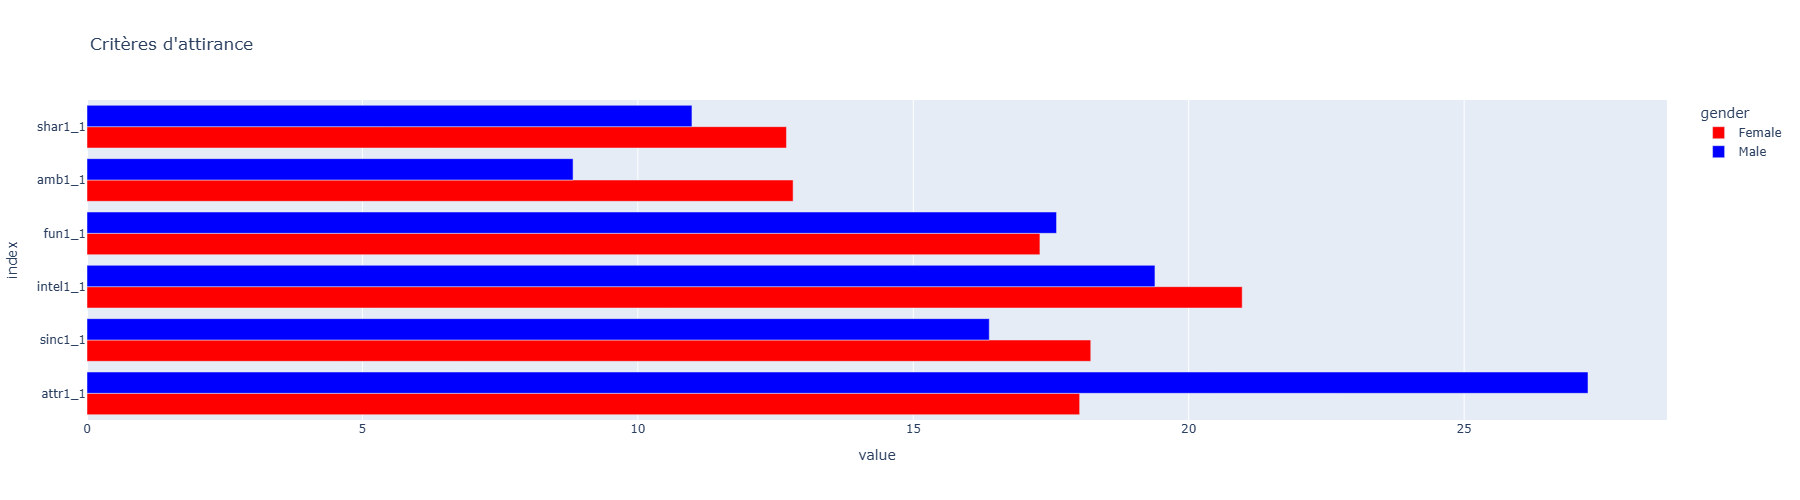

In [18]:
attirance = px.bar(
    all_pref,
    y=all_pref.index,
    x=all_pref.value,
    labels={"x": "Moyenne", "y": "Attribut"},
    color="gender",
    barmode="group",
    color_discrete_map={
        "Female": "red",
        "Male": "blue"
        },
    orientation='h',
    title="Critères d'attirance"
)
attirance.update_layout(width=1800, height=500)
attirance.show()

show_images(attirance, "../images/attirance.png")


On constate que les femmes valorisent chez les hommes l'intelligence, la sincérité et l'attractivité physique.  
Tandis que les hommes privilégient massivement le physique, suivi de l'intelligence et du côté fun.

En queue de peloton, les femmes accordent peu d'importance aux centres d'intérêts/hobbies partagés de l'homme.  
Les hommes, eux, se montrent les moins sensibles à l'ambition des femmes.

### b) Importance de l'attractivité physique
Les participants pensent ils que le physique est très important pour choisir un partenaire ? Et est-ce que ça change vraiment leurs décisions de match ?

In [19]:
all_attr_data = data_unique[["attr1_1", "attr1_2", "attr7_2", "attr1_3", "attr7_3"]]
all_attr1_data = all_attr_data[all_attr_data[["attr1_1", "attr1_2", "attr1_3"]].notna().all(axis=1)].mean()
all_attr7_data = all_attr_data[all_attr_data[["attr7_2", "attr7_3"]].notna().all(axis=1)].mean()

all_attr1_data.drop(["attr7_2", "attr7_3"], inplace=True)
attr1 = all_attr1_data.to_frame('value')

all_attr7_data.drop(["attr1_1", "attr1_2", "attr1_3"], inplace=True)
attr7 = all_attr7_data.to_frame('value')

In [20]:
attr1.reset_index(drop=True, inplace=True)
attr1.index = attr1.index + 1
attr1["attrx"] = "attr1_x"

attr7.reset_index(drop=True, inplace=True)
attr7.index = attr7.index + 2
attr7["attrx"] = "attr7_x"

all_attr = pd.concat([attr1, attr7])


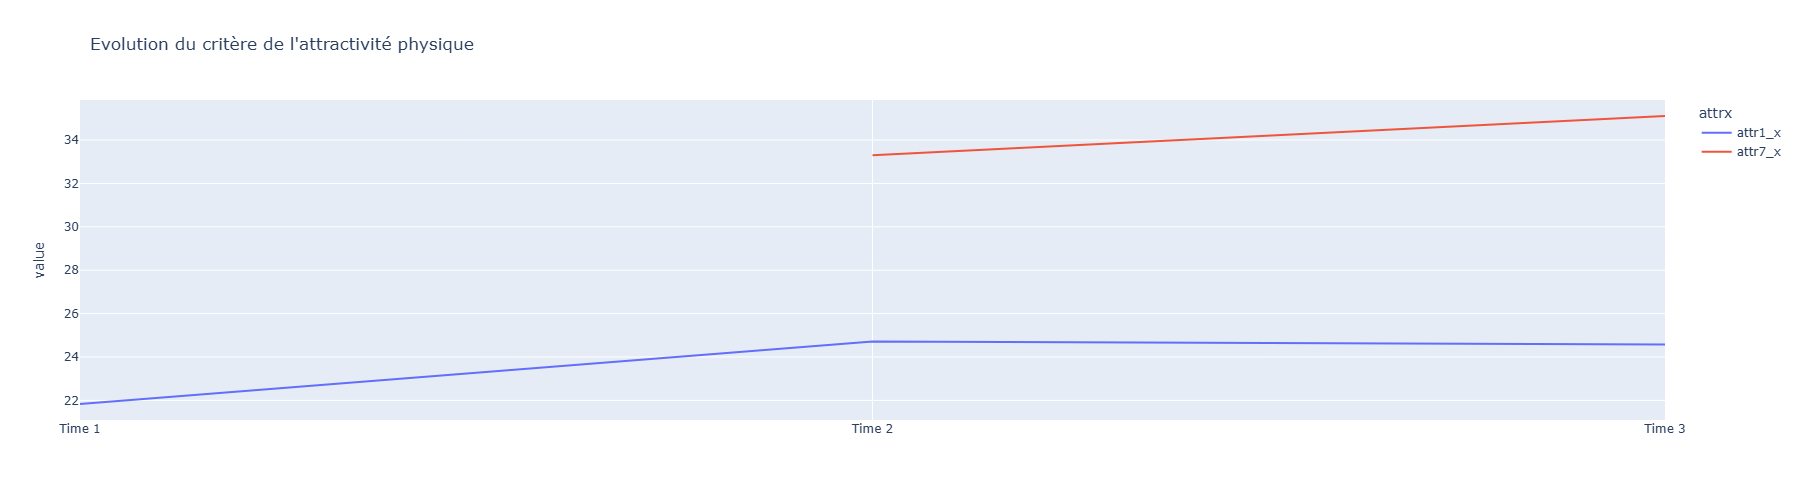

In [21]:
attr_fig = px.line(
    all_attr,
    x=all_attr.index,
    y="value",
    color="attrx",
    labels={"x": "Time"},
    title="Evolution du critère de l'attractivité physique"
)

attr_fig.update_layout(
    xaxis_title=None,
    xaxis=dict(
        tickmode="array",
        tickvals=[1, 2, 3],
        ticktext=["Time 1", "Time 2", "Time 3"]
    ),
    width=1800, 
    height=500

)
attr_fig.show()

show_images(attr_fig, "../images/attr_fig.png")

Après le speed dating, très peu de gens ont répondu aux questionnaires (Time 2 et 3).  

En violet : ce que les participants pensent de l'importance du physique au fil du temps.  
La courbe est ascendante, ils se rendent compte que le physique compte plus qu'ils ne le pensaient au début.  

En orange : l'impact réel du physique sur leurs choix de match.  
La courbe est également ascendante. En analysant leurs décisions, ils voient que le physique a vraiment influencé leurs "oui".  

Au début, les participants pensaient que le physique n'était pas si important. Après réflexion, ils réalisent que c'était quand même un critère majeur dans leurs choix !

### c) Interets communs vs meme origine ethnique
Est-ce que partager les mêmes centres d'intérêt est plus important que d'avoir la même origine ethnique pour qu'il y ait un match ?

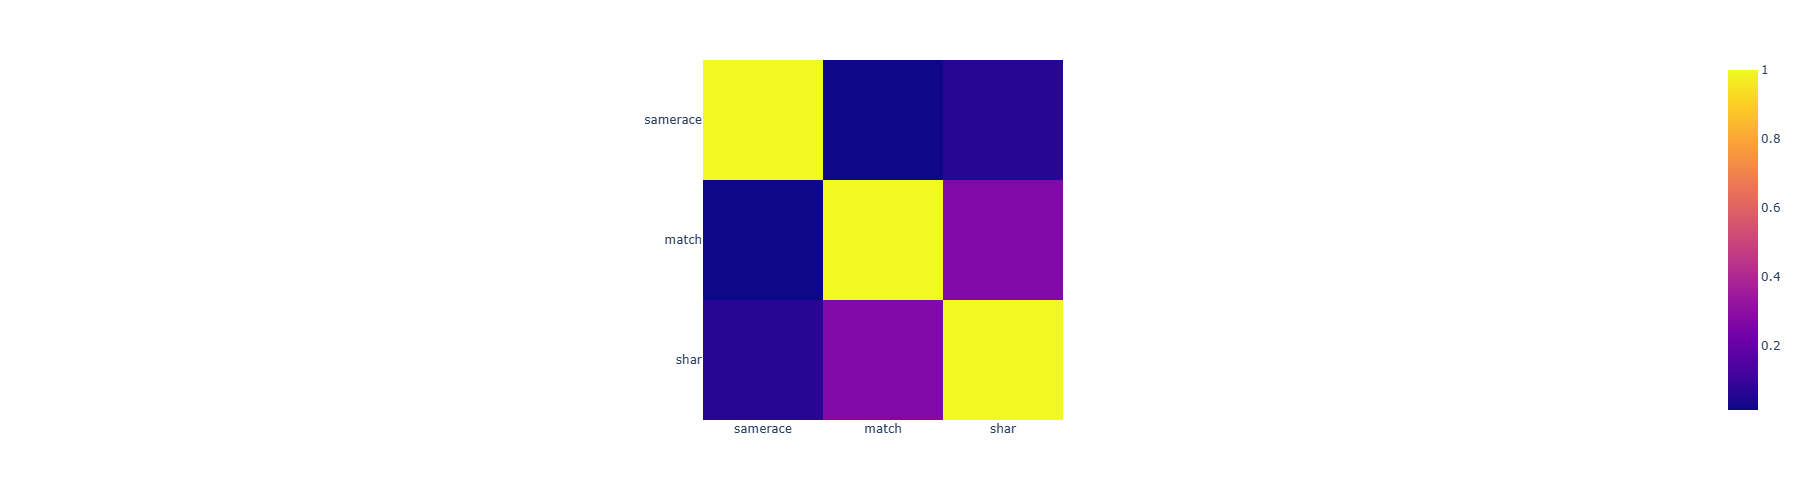

In [22]:
data_match_comp = data[["samerace", "match", "shar"]].copy()

yes_no_inverse_map = {
    "no": 0,
    "yes": 1
}
data_match_comp['samerace'] = data_match_comp['samerace'].map(yes_no_inverse_map)
data_match_comp['match'] = data_match_comp['match'].map(yes_no_inverse_map)

corr_race_match_shar = px.imshow(data_match_comp.corr(), width=1800, height=500)
corr_race_match_shar.show()

show_images(corr_race_match_shar, "../images/corr_race_match_shar.png")

Le graphique montre que les centres d'intéret communs donnent beaucoup plus de matches que d'avoir la même origine ethnique.  
Des centres d'intérêt communs permettent d'avoir un match avec 26 fois plus de chances que la même origine ethnique.

### d) Analyse de la valeur percue
Les notes que se donnent les participants, correspondent-elles à ce que les autres pensent vraiment d'eux ?

In [23]:
own_value = data[["iid", "attr3_1", "sinc3_1", "fun3_1", "intel3_1", "amb3_1"]].drop_duplicates(subset="iid")
own_value.drop(columns="iid", inplace=True)
own_value.columns = ["attr", "sinc", "intel", "fun", "amb"]
own_value_mean = own_value.mean().copy()

value_from_others = data.groupby("iid")[["iid", "attr_o", "sinc_o", "intel_o", "fun_o", "amb_o"]].mean()
value_from_others.drop(columns="iid", inplace=True)
value_from_others.columns = ["attr", "sinc", "intel", "fun", "amb"]
value_from_others.reset_index(inplace=True, drop=True)
value_from_others_mean = value_from_others.mean().copy()

perception_from_others = data.groupby("iid")[["iid", "attr5_1", "sinc5_1", "intel5_1", "fun5_1", "amb5_1"]].mean()
perception_from_others.drop(columns="iid", inplace=True)
perception_from_others.columns = ["attr", "sinc", "intel", "fun", "amb"]
perception_from_others.reset_index(inplace=True, drop=True)
perception_from_others_mean = perception_from_others.mean().copy()

all_value_data = pd.concat([own_value_mean, value_from_others_mean, perception_from_others_mean]).reset_index()
all_value_data.columns = ["critere", "value"]
all_value_data['group'] = ['own']*5 + ['other']*5 + ['other_perception']*5


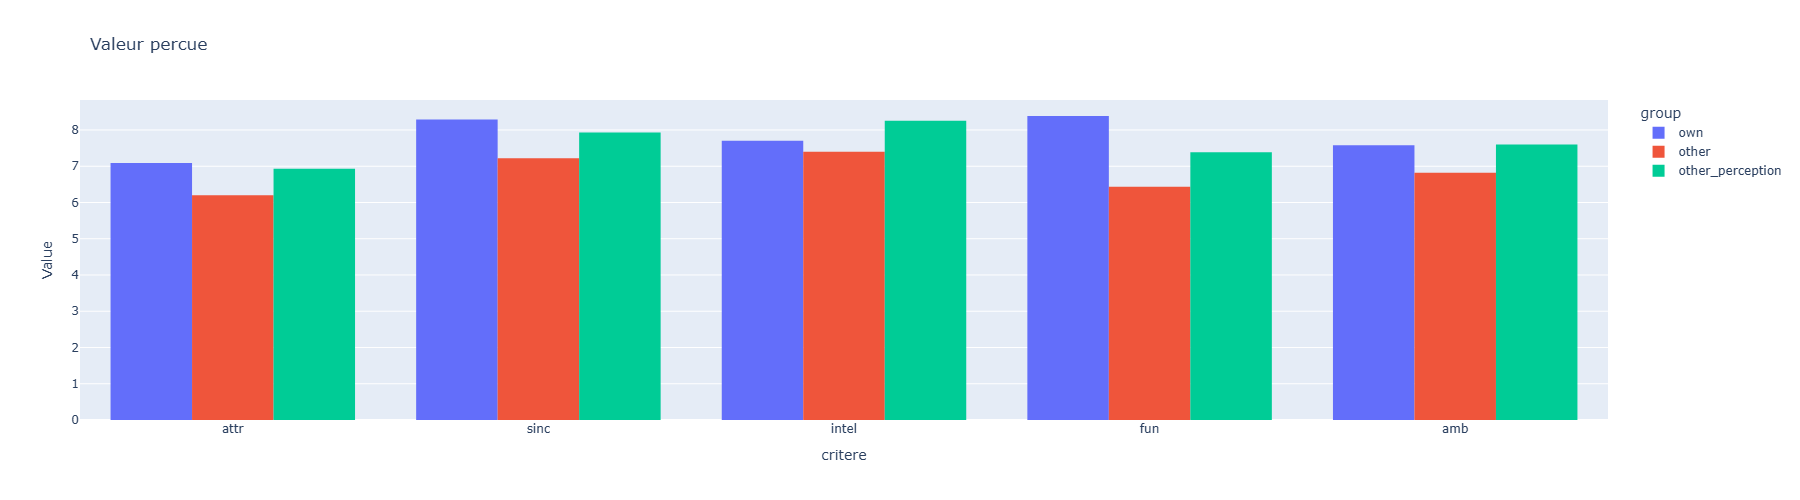

In [24]:
value_graph = px.histogram(
    all_value_data,
    y="value",
    x="critere",
    color="group",
    barmode="group",
    title="Valeur percue"
)
value_graph.update_layout(
    yaxis_title="Value",
    width=1800, 
    height=500
)
value_graph.show()

show_images(value_graph, "../images/value_graph.png")

En violet : la note que chaque personne se donne à elle-même.  
En rouge : la note que les partenaires lui donnent.  
En vert : la note, que la personne pense que les autres vont lui donner.  

Résultat : tout le monde se trouve mieux que ce que les autres pensent vraiment.  

### e) 2e rendez vous
Faut-il être le 1e ou le dernier partenaire de la soirée pour avoir plus de chances de matcher ?

In [25]:
data["is_first"] = data["order"] == 1
data["is_last"] = data["round"] == data["order"]

matches_data = data[data["match"] == "yes"]

first = (matches_data["is_first"] == True).sum()
last = (matches_data["is_last"] == True).sum()
other = ((matches_data["is_first"] == False) & (matches_data["is_last"] == False)).sum()

second_rdv = pd.DataFrame(
    {
        "order": ["First", "Last", "Other"],
        "value": [first, last, other]
    }
)

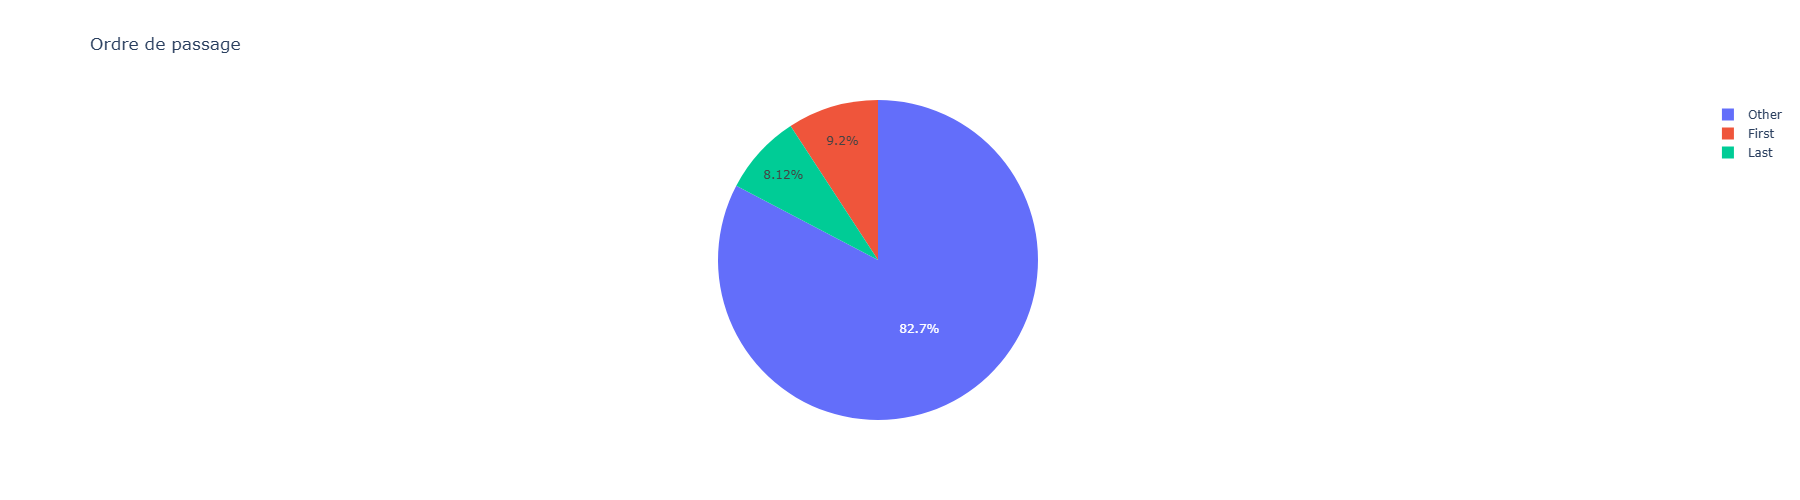

In [26]:
second_rdv_graph = px.pie(
    second_rdv,
    values="value", 
    names="order",
    title="Ordre de passage"
)
second_rdv_graph.update_layout(
    width=1800, 
    height=500
)
second_rdv_graph.show()

show_images(second_rdv_graph, "../images/second_rdv_graph.png")

Que le participant soit le 1e ou le dernier partenaire de la soirée, n'a aucun impact sur le fait d'avoir un match.